In [2]:
!pip install feature_engine

   ---------------------------------------- 0.0/375.0 kB ? eta -:--:--
   --- ----------------------------------- 30.7/375.0 kB 660.6 kB/s eta 0:00:01
   ------ -------------------------------- 61.4/375.0 kB 825.8 kB/s eta 0:00:01
   ----------- -------------------------- 112.6/375.0 kB 939.4 kB/s eta 0:00:01
   ----------------- -------------------- 174.1/375.0 kB 952.6 kB/s eta 0:00:01
   ---------------------- --------------- 225.3/375.0 kB 986.4 kB/s eta 0:00:01
   ----------------------------- ---------- 276.5/375.0 kB 1.0 MB/s eta 0:00:01
   -------------------------------- ----- 317.4/375.0 kB 984.6 kB/s eta 0:00:01
   ---------------------------------------- 375.0/375.0 kB 1.0 MB/s eta 0:00:00
   ---------------------------------------- 0.0/11.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.6 MB ? eta -:--:--
   ---------------------------------------- 0.1/11.6 MB 1.1 MB/s eta 0:00:11
   ---------------------------------------- 0.1/11.6 MB 660.6 kB/s eta 0

  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.30.0 requires protobuf<5,>=3.20, but you have protobuf 5.28.3 which is incompatible.


In [51]:
pip install -U ipywidgets

  Using cached comm-0.2.2-py3-none-any.whl.metadata (3.7 kB)
   ---------------------------------------- 0.0/139.8 kB ? eta -:--:--
   -- ------------------------------------- 10.2/139.8 kB ? eta -:--:--
   -------- ------------------------------ 30.7/139.8 kB 660.6 kB/s eta 0:00:01
   -------- ------------------------------ 30.7/139.8 kB 660.6 kB/s eta 0:00:01
   --------------------------------- ---- 122.9/139.8 kB 722.1 kB/s eta 0:00:01
   -------------------------------------- 139.8/139.8 kB 753.1 kB/s eta 0:00:00
Using cached comm-0.2.2-py3-none-any.whl (7.2 kB)
   ---------------------------------------- 0.0/214.4 kB ? eta -:--:--
   - -------------------------------------- 10.2/214.4 kB ? eta -:--:--
   --------------- ------------------------ 81.9/214.4 kB 1.2 MB/s eta 0:00:01
   ---------------------- ----------------- 122.9/214.4 kB 1.0 MB/s eta 0:00:01
   ------------------------- ------------ 143.4/214.4 kB 853.3 kB/s eta 0:00:01
   ---------------------------------- --- 19

In [1]:
import pandas as pd
import numpy as np

from pgmpy.estimators import HillClimbSearch, MaximumLikelihoodEstimator, BicScore
from pgmpy.models import BayesianNetwork
from pgmpy.inference import VariableElimination

import ipywidgets
import networkx as nx
import matplotlib.pyplot as plt
import time

import warnings
warnings.filterwarnings('ignore')

In [18]:
df_credit = pd.read_csv('./Data.txt', delimiter=";")
df_credit.shape

(1225, 15)

In [19]:
df_credit.isnull().sum()

YOB       0
NKID      0
DEP       0
PHON      0
SINC      0
AES       0
DAINC     0
RES       0
DHVAL     0
DMORT     0
DOUTM     0
DOUTL     0
DOUTHP    0
DOUTCC    0
BAD       0
dtype: int64

In [20]:
df_credit

,YOB,NKID,DEP,PHON,SINC,AES,DAINC,RES,DHVAL,DMORT,DOUTM,DOUTL,DOUTHP,DOUTCC,BAD
0,19.0,4.0,0.0,1,0.0,R,0.0,O,14464.0,4.0,0.0,0.0,0.0,0.0,0.0
1,41.0,2.0,0.0,1,0.0,P,36000.0,O,0.0,0.0,280.0,664.0,0.0,80.0,0.0
2,66.0,0.0,0.0,1,0.0,N,30000.0,N,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,51.0,2.0,0.0,1,0.0,P,464.0,O,24928.0,8464.0,584.0,320.0,0.0,60.0,0.0
4,65.0,0.0,0.0,1,0.0,P,15000.0,P,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1220,52.0,4.0,1.0,1,0.0,V,37764.0,U,0.0,0.0,0.0,340.0,0.0,0.0,0.0
1221,56.0,3.0,0.0,1,1200.0,P,31500.0,O,6928.0,46464.0,784.0,256.0,0.0,0.0,1.0
1222,60.0,0.0,0.0,1,0.0,E,46800.0,O,11392.0,928.0,1144.0,680.0,0.0,108.0,0.0
1223,20.0,0.0,0.0,1,0.0,R,0.0,N,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [21]:
df_train = df_credit[:900]
df_test = df_credit[900:]
df_credit.shape

(1225, 15)

In [22]:
df_train.shape

(900, 15)

In [23]:
df_test.shape

(325, 15)

  0%|          | 0/1000000 [00:00<?, ?it/s]

StopIteration: 

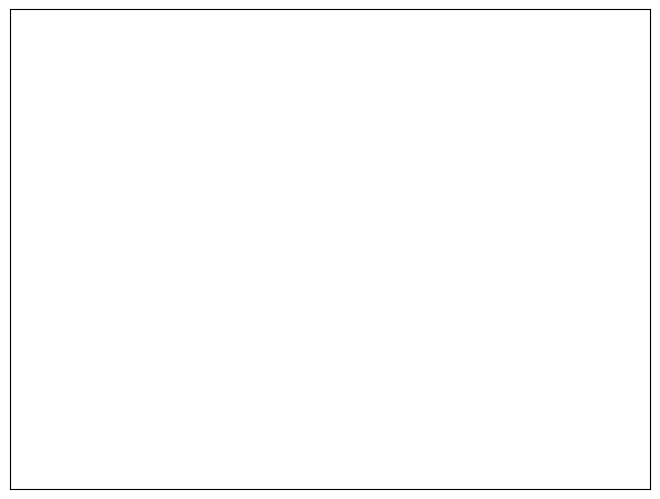

In [24]:
hc = HillClimbSearch(df_train)
best_model = hc.estimate(scoring_method=BicScore(df_train))
edges = list(best_model.edges())
model = BayesianNetwork(edges)

nx.draw(best_model)
plt.draw()

%matplotlib inline
plt.figure(figsize=(15,10))
plt.show()

In [12]:
best_model

  0%|          | 0/1000000 [00:00<?, ?it/s]

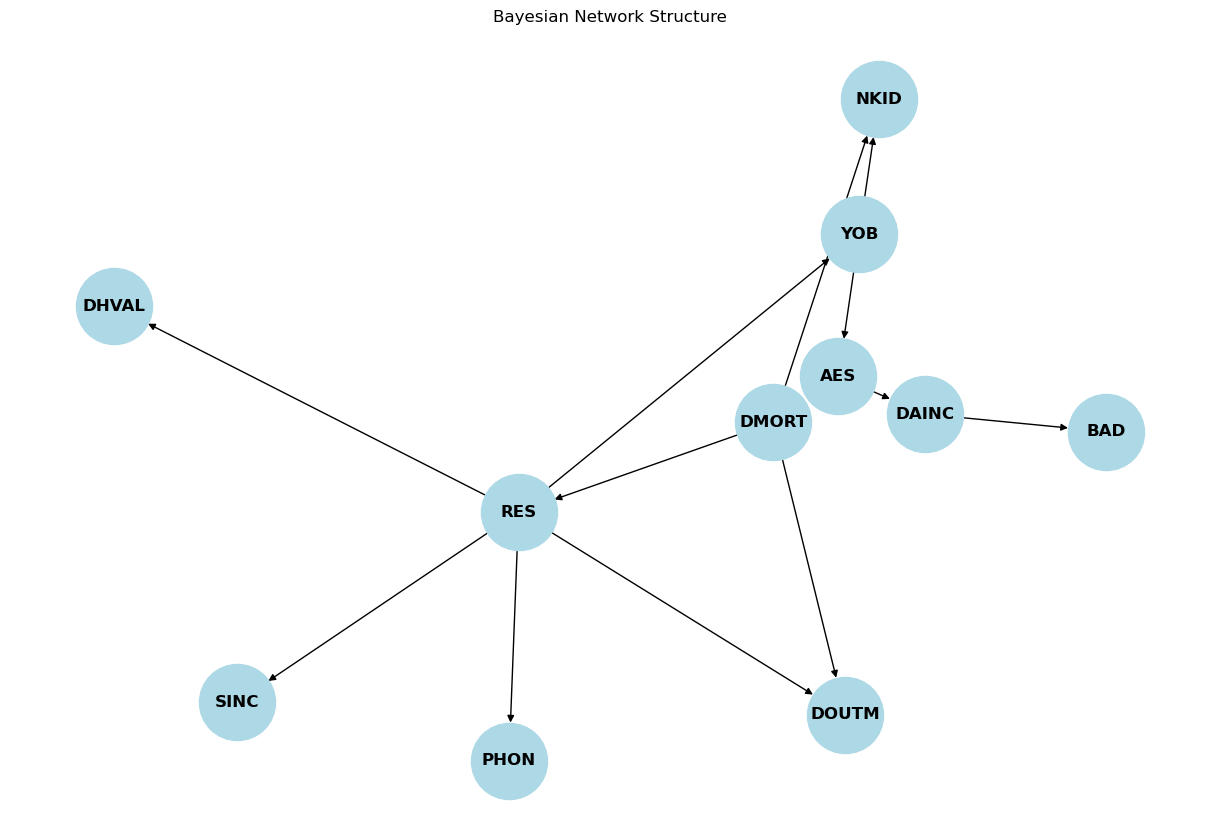

In [29]:
import pandas as pd
from pgmpy.estimators import HillClimbSearch, BicScore
from pgmpy.models import BayesianNetwork
import networkx as nx
import matplotlib.pyplot as plt

data = pd.read_csv('./Data.txt', delimiter=";")


# Define features and target
X = data.drop(columns=['BAD'])
y = data['BAD']

# Preprocessing as before
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import KBinsDiscretizer

numerical_cols = X.select_dtypes(include=['float64']).columns
categorical_cols = X.select_dtypes(exclude=['float64']).columns

# Impute missing values
numerical_imputer = SimpleImputer(strategy='median')
categorical_imputer = SimpleImputer(strategy='most_frequent')
X[numerical_cols] = numerical_imputer.fit_transform(X[numerical_cols])
X[categorical_cols] = categorical_imputer.fit_transform(X[categorical_cols])

# Apply binning
binning = KBinsDiscretizer(n_bins=4, encode='ordinal', strategy='quantile')
X[numerical_cols] = binning.fit_transform(X[numerical_cols])

# Combine features and target for learning
X['BAD'] = y

# Bayesian Network structure learning
hc = HillClimbSearch(X)
model = hc.estimate(scoring_method=BicScore(X))

# Create a Bayesian Network model
bayesian_model = BayesianNetwork(model.edges())

graph = nx.DiGraph()
graph.add_edges_from(bayesian_model.edges())

# Plot the learned structure
plt.figure(figsize=(12, 8))
nx.draw(graph, with_labels=True, node_size=3000, node_color="lightblue", font_size=12, font_weight="bold")
plt.title("Bayesian Network Structure")
plt.show()

In [37]:
import pandas as pd
from pgmpy.estimators import HillClimbSearch, BicScore
from pgmpy.models import BayesianNetwork
import networkx as nx
import matplotlib.pyplot as plt

data = pd.read_csv('./Data.txt', delimiter=";")
# Preprocessing based on description

# 1. YOB (Year of Birth) - Convert year to age and create age bins
data['YOB'] = data['YOB'].replace(99, pd.NA)
data = data.dropna(subset=['YOB'])  # Drop rows where YOB is NA
data['YOB'] = 2024 - data['YOB']  # Convert to age
data['YOB'] = pd.cut(data['YOB'], bins=[0, 20, 30, 40, 50, 60, 100], labels=False)  # Age bins

# 2. NKID and DEP (Number of Children and Other Dependents)
data['NKID'] = data['NKID'].fillna(0)
data['DEP'] = data['DEP'].fillna(0)

# 3. PHON (Home Phone - binary)
data['PHON'] = data['PHON'].fillna(0)

# 4. SINC and DAINC (Income) - Bin based on quartiles with duplicates handling
data['SINC'] = data['SINC'].fillna(0)
data['DAINC'] = data['DAINC'].fillna(0)
data['SINC'] = pd.qcut(data['SINC'], q=4, labels=False, duplicates="drop")
data['DAINC'] = pd.qcut(data['DAINC'], q=4, labels=False, duplicates="drop")

# 5. AES (Applicant's Employment Status)
aes_mapping = {'V': 1, 'W': 2, 'M': 3, 'P': 4, 'B': 5, 'R': 6, 'E': 7, 'T': 8, 'U': 9, 'N': 10, 'Z': 0}
data['AES'] = data['AES'].map(aes_mapping)

# 6. RES (Residential Status)
res_mapping = {'O': 1, 'F': 2, 'U': 3, 'P': 4, 'N': 5, 'Z': 0}
data['RES'] = data['RES'].map(res_mapping)

# 7. DHVAL (Value of Home) - Bin based on quantiles or custom bins if needed
data['DHVAL'] = data['DHVAL'].replace([0, 1, pd.NA], 0)
data['DHVAL'] = pd.qcut(data['DHVAL'].replace(0, pd.NA), q=4, labels=False, duplicates="drop").fillna(0)  # Bin home values

# 8. DMORT, DOUTM, DOUTL, DOUTHP, DOUTCC (Financial Outgoings)
for col in ['DMORT', 'DOUTM', 'DOUTL', 'DOUTHP', 'DOUTCC']:
    data[col] = data[col].fillna(0)

# Remove any remaining rows with NA values
data = data.dropna()

# Separate features and target
X = data.drop(columns=['BAD'])
y = data['BAD']

# Structure learning for Bayesian Network
X['BAD'] = y  # Include target in data for structure learning
hc = HillClimbSearch(X)
model = hc.estimate(scoring_method=BicScore(X))

# Create a Bayesian Network model
bayesian_model = BayesianNetwork(model.edges())

# Convert to a networkx DiGraph for visualization
graph = nx.DiGraph()
graph.add_edges_from(bayesian_model.edges())

# Plot the learned structure
plt.figure(figsize=(12, 8))
nx.draw(graph, with_labels=True, node_size=3000, node_color="lightblue", font_size=12, font_weight="bold")
plt.title("Bayesian Network Structure")
plt.show()


TypeError: boolean value of NA is ambiguous

In [38]:
import pandas as pd
import numpy as np
from pgmpy.estimators import HillClimbSearch, BicScore
from pgmpy.models import BayesianNetwork
import networkx as nx
import matplotlib.pyplot as plt

data = pd.read_csv('./Data.txt', delimiter=";")
# Preprocessing based on description

# 1. YOB (Year of Birth) - Convert year to age and create age bins
data['YOB'] = data['YOB'].replace(99, np.nan)
data = data.dropna(subset=['YOB'])  # Drop rows where YOB is NA
data['YOB'] = 2024 - data['YOB']  # Convert to age
data['YOB'] = pd.cut(data['YOB'], bins=[0, 20, 30, 40, 50, 60, 100], labels=False)  # Age bins

# 2. NKID and DEP (Number of Children and Other Dependents)
data['NKID'] = data['NKID'].fillna(0)
data['DEP'] = data['DEP'].fillna(0)

# 3. PHON (Home Phone - binary)
data['PHON'] = data['PHON'].fillna(0)

# 4. SINC and DAINC (Income) - Bin based on quartiles with duplicates handling
data['SINC'] = data['SINC'].fillna(0)
data['DAINC'] = data['DAINC'].fillna(0)
data['SINC'] = pd.qcut(data['SINC'], q=4, labels=False, duplicates="drop")
data['DAINC'] = pd.qcut(data['DAINC'], q=4, labels=False, duplicates="drop")

# 5. AES (Applicant's Employment Status)
aes_mapping = {'V': 1, 'W': 2, 'M': 3, 'P': 4, 'B': 5, 'R': 6, 'E': 7, 'T': 8, 'U': 9, 'N': 10, 'Z': 0}
data['AES'] = data['AES'].map(aes_mapping)

# 6. RES (Residential Status)
res_mapping = {'O': 1, 'F': 2, 'U': 3, 'P': 4, 'N': 5, 'Z': 0}
data['RES'] = data['RES'].map(res_mapping)

# 7. DHVAL (Value of Home) - Replace 0 and 1 with NaN, then bin
data['DHVAL'] = data['DHVAL'].replace([0, 1], np.nan)
data['DHVAL'] = pd.qcut(data['DHVAL'], q=4, labels=False, duplicates="drop").fillna(0)  # Bin home values

# 8. DMORT, DOUTM, DOUTL, DOUTHP, DOUTCC (Financial Outgoings)
for col in ['DMORT', 'DOUTM', 'DOUTL', 'DOUTHP', 'DOUTCC']:
    data[col] = data[col].fillna(0)

# Remove any remaining rows with NA values
data = data.dropna()

# Separate features and target
X = data.drop(columns=['BAD'])
y = data['BAD']

# Structure learning for Bayesian Network
X['BAD'] = y  # Include target in data for structure learning
hc = HillClimbSearch(X)
model = hc.estimate(scoring_method=BicScore(X))

# Create a Bayesian Network model
bayesian_model = BayesianNetwork(model.edges())

# Convert to a networkx DiGraph for visualization
graph = nx.DiGraph()
graph.add_edges_from(bayesian_model.edges())

# Plot the learned structure
plt.figure(figsize=(12, 8))
nx.draw(graph, with_labels=True, node_size=3000, node_color="lightblue", font_size=12, font_weight="bold")
plt.title("Bayesian Network Structure")
plt.show()


  0%|          | 0/1000000 [00:00<?, ?it/s]

ValueError: math domain error